In [12]:
# 08/2025
###########################################################################################
# using linear model to test correlation
#	Testing correlation
#   Plotting results
#   Diagnostics of the model
#   non-parametric alternative if necessary (not yet implemented)

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [14]:
curProject = 'amputee'
curRegion = 'CSSyl'
curRoot = 'C'  # 'C' or 'D'
curDistType = 'min'         ############################ !!!!!!!!!!!!!!!  CHANGE  !!!!!!!!!!!!!!  ###########################

################################  Read the CSV file into a DataFrame  ################################
#file_path = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\{curRegion}_combined_{curDistType}_2024.csv'
file_path = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\{curRegion}_withMorphometry_asy_{curDistType}_2024.csv'
#file_path = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\{curRegion}_combined_{curDistType}_2025.csv'
print(file_path)

merged_info = pd.read_csv(file_path)
print(len(merged_info))
#print("Data types:\n", df_loaded.dtypes)

# Add numeric columns for tests
merged_info['Gender_num'] = merged_info['Gender'].map({'M': 0, 'F': 1})    # Create the new column 'Category_num'
merged_info['Hemisphere_num'] = merged_info['Hemisphere'].map({'Left': 1, 'Right': 2})    # Create the new column 'Category_num'
#merged_info['Study_num'] = merged_info['Study'].map({'1': 1, '2': 2})    # Create the new column 'Category_num'
merged_info['Study_num'] = pd.to_numeric(merged_info['Study'], errors='coerce')  # Study is already stored as integer


# Make sure categorical variables are treated as such
merged_info['Group'] = merged_info['Group'].astype('category')
merged_info['Gender'] = merged_info['Gender'].astype('category')
merged_info['Study'] = merged_info['Study'].astype('category')


C:\B_projWIP\proj_amputee\Analysis_2025\CSSyl_withMorphometry_asy_min_2024.csv
130


In [15]:
#print(merged_info['Study'])
print(merged_info['Study'].unique())
print(merged_info['Study'].dtype)
print(merged_info['Study_num'].dtype)

[2, 1]
Categories (2, int64): [1, 2]
category
int64


In [16]:
#merged_info.isna().sum()
nan_counts = merged_info.isna().sum().sort_values(ascending=False)
#print(nan_counts)

In [29]:
################################  Data Selection  ################################
left_hem = merged_info[merged_info['Hemisphere'] == 'Left']
right_hem = merged_info[merged_info['Hemisphere'] == 'Right']
controls = merged_info[merged_info['Group'] == 'CTR'] 
congenitals = merged_info[merged_info['Group'] == 'CONG']
amputees = merged_info[merged_info['Group'] == 'AMP']

# DataFrame with missing hemisphere:
missing_hem = merged_info[
    ((merged_info['Hemisphere'] == 'Left') & (merged_info['AmpSide'] == 'R')) |
    ((merged_info['Hemisphere'] == 'Right') & (merged_info['AmpSide'] == 'L'))
]

# DataFrame with using hemisphere:
using_hem = merged_info[
    ((merged_info['Hemisphere'] == 'Left') & (merged_info['AmpSide'] == 'L')) |
    ((merged_info['Hemisphere'] == 'Right') & (merged_info['AmpSide'] == 'R'))
]

# Adding controls
missing_hem_withControl = pd.concat([missing_hem, controls], ignore_index=True)
using_hem_withControl = pd.concat([using_hem, controls], ignore_index=True)

# using and missing_hem of only congenitals
missing_hem_onlyCong = congenitals[
    ((congenitals['Hemisphere'] == 'Left') & (congenitals['AmpSide'] == 'R')) |
    ((congenitals['Hemisphere'] == 'Right') & (congenitals['AmpSide'] == 'L'))
]
missing_hem_onlyCong_rightHem = missing_hem_onlyCong[missing_hem_onlyCong['Hemisphere'] == 'Right']

using_hem_onlyCong = congenitals[
    ((congenitals['Hemisphere'] == 'Left') & (congenitals['AmpSide'] == 'L')) |
    ((congenitals['Hemisphere'] == 'Right') & (congenitals['AmpSide'] == 'R'))
]

# using and missing_hem of only amputees
missing_hem_onlyAmp = amputees[
    ((amputees['Hemisphere'] == 'Left') & (amputees['AmpSide'] == 'R')) |
    ((amputees['Hemisphere'] == 'Right') & (amputees['AmpSide'] == 'L'))
]
using_hem_onlyAmp = amputees[
    ((amputees['Hemisphere'] == 'Left') & (amputees['AmpSide'] == 'L')) |
    ((amputees['Hemisphere'] == 'Right') & (amputees['AmpSide'] == 'R'))
]


In [18]:
######################################  Parametric linear model  #######################################

In [19]:
############################ !!!!!!!!!!!!!!!  CHANGE  !!!!!!!!!!!!!!  ###########################

# Define the dataset
# using_hem, missing_hem, right_hem, left_hem, merged_info, using_hem_onlyCong, missing_hem_onlyCong
# using_hem_onlyAmp, missing_hem_onlyAmp
cur_info = missing_hem_onlyAmp 

In [20]:
################################  LM tests, parametric, shape vs duration_amputation  #################################
##  test correlation between duration_amputation and shape, morphometry and asymmetry  ################################

# List of shape measures
cur_info.rename(columns={'amputatio level': 'amputatio_level'}, inplace=True)

usage_measures = ['duration_amputation']
#usage_measures = ['Prosthesisusage','Stumpusage','amputatio_level', 'missinghand','intacthand','residualarm','intactarm','lips','feet'] 
shape_measures = ['surface_talairach','maxdepth_talairach','meandepth_talairach','hull_junction_length_talairach',
                     'GM_thickness','opening','iso1','UMAP1_U2',
                  'surface_talairach_asy','maxdepth_talairach_asy','meandepth_talairach_asy','hull_junction_length_talairach_asy',
                     'GM_thickness_asy','opening_asy','iso1_asy','UMAP1_U2_asy'
                    ]   

# Dictionary to store results
model_results = {}

for shape_measure in shape_measures:
    for usage_measure in usage_measures:
        
        ## Does brain reorganization predict shape measurements?
        #formula = f'{shape_measure} ~ {usage_measure} + Hemisphere + AgeScan + Gender + Study'
        formula = f'{shape_measure} ~ {usage_measure} + Hemisphere + AgeScan'   # for amputees 
        #formula = f'{shape_measure} ~ {usage_measure} + Hemisphere + Study'  # for congenitals, remove AgeScan          
        
        model = smf.ols(formula, data=cur_info).fit()
        model_results[shape_measure] = model
        print(f'========================= Results for {shape_measure} and {usage_measure} ===========================')
        print(model.summary())
        print('\n')

========================= Results for surface_talairach and duration_amputation ===========================
                            OLS Regression Results                            
Dep. Variable:      surface_talairach   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                 -0.049
Method:                 Least Squares   F-statistic:                    0.7687
Date:                Tue, 07 Oct 2025   Prob (F-statistic):              0.533
Time:                        17:28:07   Log-Likelihood:                -125.18
No. Observations:                  16   AIC:                             258.4
Df Residuals:                      12   BIC:                             261.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
--------------

C:\Users\joyca\AppData\Local\Temp\ipykernel_34544\3196023757.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cur_info.rename(columns={'amputatio level': 'amputatio_level'}, inplace=True)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib

========================= Results for hull_junction_length_talairach and duration_amputation ===========================
                                  OLS Regression Results                                  
Dep. Variable:     hull_junction_length_talairach   R-squared:                       0.227
Model:                                        OLS   Adj. R-squared:                  0.033
Method:                             Least Squares   F-statistic:                     1.172
Date:                            Tue, 07 Oct 2025   Prob (F-statistic):              0.361
Time:                                    17:28:07   Log-Likelihood:                -62.232
No. Observations:                              16   AIC:                             132.5
Df Residuals:                                  12   BIC:                             135.6
Df Model:                                       3                                         
Covariance Type:                        nonrobust           

C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)


========================= Results for hull_junction_length_talairach_asy and duration_amputation ===========================
                                    OLS Regression Results                                    
Dep. Variable:     hull_junction_length_talairach_asy   R-squared:                       0.364
Model:                                            OLS   Adj. R-squared:                  0.205
Method:                                 Least Squares   F-statistic:                     2.292
Date:                                Tue, 07 Oct 2025   Prob (F-statistic):              0.130
Time:                                        17:28:08   Log-Likelihood:                 26.529
No. Observations:                                  16   AIC:                            -45.06
Df Residuals:                                      12   BIC:                            -41.97
Df Model:                                           3                                         
Covariance Type:    

C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)


C:\B_projWIP\proj_amputee\Analysis_2025\Plots\min_cor_missing_hem_onlyCong_isoU_heatmap.png


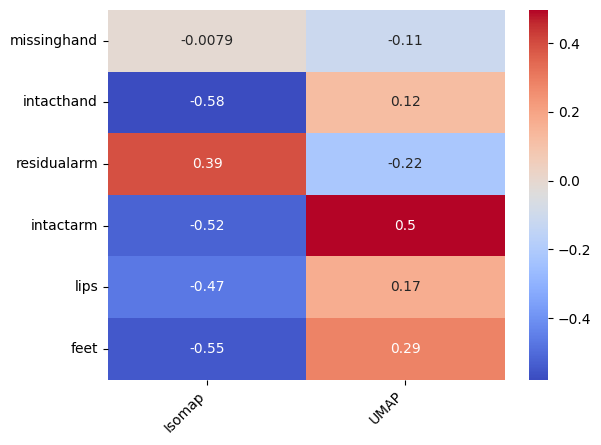

In [23]:
cur_info = missing_hem_onlyCong   #########  !!!! Modify !!!!  #########
##########  Heatmap of correlations: for a quick summary of strength and direction  ########
# shows all 7 × 4 predictor-response correlations numerically  
# or show only relevant ones, possible to relabel x-axis values

predictor_labels = {
    'iso1': 'Isomap',
    'iso2': 'Isomap 2',
    'iso3': 'Isomap 3',
    'UMAP1_U1': 'UMAP1 Dim1',
    'UMAP1_U2': 'UMAP',
    'UMAP1_U3': 'UMAP1 Dim3',
    'UMAP1_U4': 'UMAP1 Dim4',
    'UMAP2_U3': 'UMAP2 Dim3',
    'UMAP2_U4': 'UMAP2 Dim4'
}

#predictors = ['iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP1_U4','UMAP2_U3','UMAP2_U4']
#responses = ['Prosthesisusage','Stumpusage','amputatio level', 'missinghand','intacthand','residualarm','intactarm','lips','feet']   
predictors = ['iso1', 'UMAP1_U2']
responses = ['missinghand','intacthand','residualarm','intactarm','lips','feet']   

# Build correlation matrix
corr_matrix = cur_info[predictors + responses].corr().loc[responses, predictors]
# Plot heatmap and capture axis
ax = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

# Replace x-axis tick labels with readable ones, use ONLY if needed
ax.set_xticklabels([predictor_labels.get(label.get_text(), label.get_text()) 
                    for label in ax.get_xticklabels()],
                   rotation=45, ha="right")

curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\Plots\{curDistType}_cor_missing_hem_onlyCong_isoU_heatmap.png'
print(curPlotName)
#plt.savefig(curPlotName, dpi=300, bbox_inches="tight")

plt.show()

In [35]:
################################  LM tests, parametric, shape vs activation measures  #################################
##  test correlation between functional activation and shape  ################################

cur_info = missing_hem_onlyCong   #########  !!!! Modify !!!!  #########
#cur_info = missing_hem_onlyCong_rightHem  # testing to see if only right hem the stats is more significant

#######################  LM tests, parametric, shape vs function  ########################
# List of shape measures
cur_info.rename(columns={'amputatio level': 'amputatio_level'}, inplace=True)
#shape_measures = ['iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP1_U4','UMAP2_U3','UMAP2_U4']
shape_measures = ['iso1', 'UMAP1_U2']
#function_measures = ['Prosthesisusage','Stumpusage','amputatio_level', 'missinghand','intacthand','residualarm','intactarm','lips','feet'] 
function_measures = ['missinghand','intacthand','residualarm','intactarm','lips','feet']   

# Dictionary to store results
model_results = {}

for measure in shape_measures:
    for function_measure in function_measures:
        
        ## Does function drive neural reorganization?
        #formula = f'{measure} ~ {function_measure} + AgeScan + Gender + Study'
        #formula = f'{measure} ~ {function_measure} + Hemisphere + Study'
        
        ## Does brain reorganization predict functional outcome?
        #formula = f'{function_measure} ~ {measure} + Hemisphere + AgeScan + Gender + Study'
        formula = f'{function_measure} ~ {measure} + Hemisphere + Study'        
        
        model = smf.ols(formula, data=cur_info).fit()
        model_results[measure] = model
        print(f'========================= Results for {measure} and {function_measure} ===========================')
        print(model.summary())
        print('\n')

C:\Users\joyca\AppData\Local\Temp\ipykernel_34544\3723068591.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cur_info.rename(columns={'amputatio level': 'amputatio_level'}, inplace=True)


========================= Results for iso1 and missinghand ===========================
                            OLS Regression Results                            
Dep. Variable:            missinghand   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                 -0.097
Method:                 Least Squares   F-statistic:                    0.3227
Date:                Wed, 08 Oct 2025   Prob (F-statistic):              0.809
Time:                        09:07:38   Log-Likelihood:                -16.538
No. Observations:                  24   AIC:                             41.08
Df Residuals:                      20   BIC:                             45.79
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

In [ ]:
#########################################  Quick confirmation  ##########################################
## Does function drive neural reorganization?
measure = 'UMAP1_U1'
function_measure = 'Stumpusage'
formula = f'{measure} ~ {function_measure} + AgeScan + Gender + Study'
model = smf.ols(formula, data=cur_info).fit()
model_results[measure] = model
print(f'========================= Results for {measure} and {function_measure} ===========================')
print(model.summary())
print('\n')

In [ ]:
#########################################  Quick confirmation  ##########################################
## Does brain reorganization predict functional outcome?
measure = 'UMAP1_U1'
function_measure = 'Stumpusage'
formula = f'{function_measure} ~ {measure} + AgeScan + Gender + Study'
model = smf.ols(formula, data=cur_info).fit()
model_results[measure] = model
print(f'========================= Results for {measure} and {function_measure} ===========================')
print(model.summary())
print('\n')

In [ ]:
##############################  Partial regression plot  ################################

# Drop rows with NaN in the relevant variables
vars_needed = ['UMAP1_U1', 'Stumpusage', 'AgeScan', 'Gender', 'Study']
df_clean = cur_info.dropna(subset=vars_needed)

# Make the plot
fig = sm.graphics.plot_partregress(
    endog='UMAP1_U1',
    exog_i='Stumpusage',
    exog_others=['AgeScan', 'Gender', 'Study'],
    data=df_clean
)

# Remove text labels (index numbers)
for ax in fig.axes:
    for txt in ax.texts:
        txt.set_visible(False)

# Change axis labels
ax = fig.axes[0]
ax.set_xlabel("StumpUsage")
ax.set_ylabel("Shape (UMAP)")

curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Analysis_2025\Plots\{measure}_{curDistType}_usingHem_cor_stumpusage.png'
print(curPlotName)
#plt.savefig(curPlotName)

plt.show()


In [ ]:
############################  Model diagnostics  #############################
#	Linearity: residuals vs. fitted plot should have no curve

# Fit model
formula = "UMAP1_U1 ~ Stumpusage + AgeScan + Gender + Study"
model = smf.ols(formula, data=cur_info).fit()

# Get fitted values and residuals
fitted_vals = model.fittedvalues
residuals = model.resid

# Plot residuals vs. fitted
plt.scatter(fitted_vals, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', linewidth=1)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted")
plt.show()


In [ ]:
#	Homoscedasticity: scale-location plot (residuals vs. fitted with equal spread)
# Get fitted values and standardized residuals
fitted_vals = model.fittedvalues
residuals = model.resid
standardized_resid = residuals / np.std(residuals)

# Square root of absolute standardized residuals
sqrt_abs_resid = np.sqrt(np.abs(standardized_resid))

plt.scatter(fitted_vals, sqrt_abs_resid, alpha=0.7)
sm.nonparametric.lowess(sqrt_abs_resid, fitted_vals)  # add smoothing line
plt.plot(fitted_vals, sm.nonparametric.lowess(sqrt_abs_resid, fitted_vals)[:, 1], color="red")

plt.xlabel("Fitted values")
plt.ylabel("√|Standardized residuals|")
plt.title("Scale-Location Plot")
plt.show()

In [ ]:
############################  For linearity: Ramsey RESET test  ##############################
# Look at the Residuals vs. fitted (no systematic curvature).
# Ramsey RESET test (general test of mis-specification):
# If p < 0.05 → possible nonlinearity / omitted variables.
    
from statsmodels.stats.diagnostic import linear_reset

reset_test = linear_reset(model, power=2, use_f=True)
print(reset_test)


In [ ]:
################### Testing heteroscedasticity  ####################
# Breusch–Pagan test
# if p < 0.05, heteroscedasticity might exist
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model.resid, model.model.exog)
labels = ['Lagrange multiplier statistic', 'p-value', 
          'f-value', 'f p-value']
print(dict(zip(labels, bp_test)))


In [ ]:
################### Testing heteroscedasticity  ####################
# White test (more general, allows for nonlinearities)
from statsmodels.stats.diagnostic import het_white

white_test = het_white(model.resid, model.model.exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, white_test)))


In [ ]:
#	Normality of residuals: Q–Q plot, 

# Get residuals from your fitted model
residuals = model.resid

# Q–Q plot
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

In [ ]:
# Shapiro–Wilk test (though with large n, visual inspection is better)
# Why “visual inspection is better with large n”?
# With a large sample size (say, n > 50–100), the Shapiro–Wilk test becomes too sensitive: 
#    it will flag tiny, irrelevant deviations as significant.
#    in practice, researchers rely more on Q–Q plots and also consider robustness of their model 
#       (linear regression is fairly robust to mild non-normality if sample size is big enough)

from scipy.stats import shapiro
stat, p = shapiro(residuals)
print('Shapiro-Wilk Test statistic=%.3f, p-value=%.3f' % (stat, p))

if p > 0.05:
    print("Residuals look normally distributed (fail to reject H0).")
else:
    print("Residuals are not normally distributed (reject H0).")

In [ ]:
###################  Heteroscedasticity Alternative Model  ####################
# Use robust standard errors:
robust_model = model.get_robustcov_results(cov_type='HC3')
print(robust_model.summary())

In [ ]:
print(cur_info.columns)

In [ ]:
########################################  Influence studies  ########################################
## Cook's distance

# Influence measures
influence = model.get_influence()
cooks_d, pvals = influence.cooks_distance

# Subject IDs
#subject_ids = cur_info['SubjID'].astype(str).tolist()   # display SubjID
#subject_ids = cur_info.index.astype(str).tolist()       # display index, to compare with the influence plot below
subject_ids = cur_info['subjName'].astype(str).tolist()  # default: display subjName

# Plot Cook's distance
plt.figure(figsize=(10, 6))
plt.stem(range(len(cooks_d)), cooks_d, markerfmt=",")  # no use_line_collection

# Custom red line: default = 4/n
n = len(cooks_d)
threshold = 4/n
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold={threshold:.3f}')

# Annotate IDs for influential points
for i, d in enumerate(cooks_d):
    if d > threshold:
        plt.text(i, d, subject_ids[i], fontsize=8, ha='right', va='bottom')

plt.xlabel("Observation index")
plt.ylabel("Cook's distance")
plt.title("Cook's Distance Plot with Subject IDs")
plt.legend()
plt.show()


In [ ]:
# Create a mapping DataFrame
index_map = cur_info.reset_index()[['index', 'subjName', 'SubjID']]

# Rename the columns for clarity
index_map.columns = ['RowIndex', 'SubjName', 'SubjID']

pd.set_option('display.max_rows', None)
print(index_map)


In [ ]:
########################################  Influence studies  ########################################
## Leverage vs. residuals squared plot
sm.graphics.influence_plot(model, criterion="cooks")
plt.show()

In [ ]:
############################################  WIP  ###############################################

In [ ]:
#########################  Non-parametric alternative (if needed) ##########################
